5. Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")

In [29]:
wego['HDWY_PCT'] = round(wego['HDWY_DEV'] / wego['SCHEDULED_HDWY'] * 100,2)

In [45]:
wego = wego[wego.SCHEDULED_HDWY != 0]

In [46]:
check = wego[['SCHEDULED_HDWY','HDWY_DEV','HDWY_PCT']].sort_values('HDWY_PCT')

In [47]:
q5 = wego[['ADHERENCE','HDWY_PCT']]

In [48]:
q5 = q5.dropna()

In [50]:
q5.describe()

,ADHERENCE,HDWY_PCT
count,265847.000000,265847.000000
mean,-3.503547,3.162494
std,6.501571,46.666776
min,-948.533333,-100.000000
25%,-4.616666,-14.170000
50%,-2.216666,0.180000
75%,-0.666666,15.500000
max,85.666666,2417.500000


In [52]:
q5.corr()

,ADHERENCE,HDWY_PCT
ADHERENCE,1.000000,-0.203726
HDWY_PCT,-0.203726,1.000000


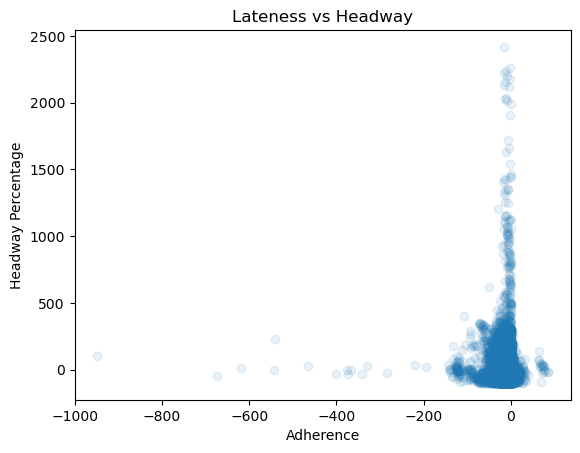

In [61]:
plt.scatter(q5.ADHERENCE, q5.HDWY_PCT, alpha=0.1, marker='o')

plt.xlabel("Adherence")
plt.ylabel("Headway Percentage")
plt.title("Lateness vs Headway")

plt.show()

In [55]:
a_q3 = q5.ADHERENCE.quantile(0.75)
a_q1 = q5.ADHERENCE.quantile(0.25)
a_IQR = a_q3 - a_q1

In [56]:
a_upper = a_q3 + 1.5 * a_IQR
a_lower = a_q1 - 1.5 * a_IQR

In [15]:
h_q3 = q5.HDWY_PCT.quantile(0.75)
h_q1 = q5.HDWY_PCT.quantile(0.25)
h_IQR = h_q3 - h_q1

h_upper = h_q3 + 1.5 * h_IQR
h_lower = h_q1 - 1.5 * h_IQR

In [57]:
q5_outliers_removed = q5[(q5.ADHERENCE <= a_upper) & (q5.ADHERENCE >= a_lower) & (q5.HDWY_PCT <= h_upper) & (q5.HDWY_PCT >= h_lower)]

In [58]:
q5_outliers_removed.corr()

,ADHERENCE,HDWY_PCT
ADHERENCE,1.000000,-0.270836
HDWY_PCT,-0.270836,1.000000


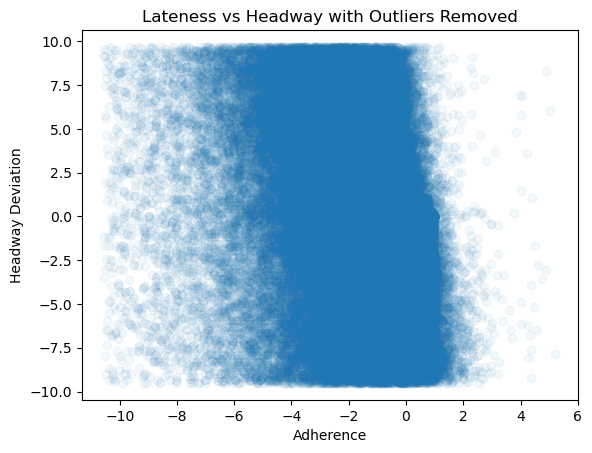

In [60]:
plt.scatter(q5_outliers_removed.ADHERENCE, q5_outliers_removed.HDWY_PCT, alpha=0.05, marker='o')

plt.xlabel("Adherence")
plt.ylabel("Headway Percentage")
plt.title("Lateness vs Headway with Outliers Removed")

plt.show()